# PCA - Topics for  Germany

### Purpose
This notebook provides an analytical deep dive into the textual structure of German public procurement notices.
Using NMF topic features and PCA, it visualizes semantic patterns, clusters, and correlations within tender texts.
The goal is to understand thematic distributions, identify dominant topics, and explore latent structures that may relate to competition or failure risk.

### Steps
- Load German Topic Dataset
- PCA for Topic Visualization
- KMeans Clustering
- Topic Correlation Heatmap

--------------------
#### Imports & Setup & Dataset
-------------------

In [2]:
# ---------------------------------------------------------
# Import moduls
# ---------------------------------------------------------

# import standard modules
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.decomposition import PCA

from sklearn.cluster import KMeans

import pickle

import sys
from pathlib import Path

In [3]:
# ---------------------------------------------------------
# Setup style
# ---------------------------------------------------------

# show all columns
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

# visualisation settings
pd.set_option('display.float_format', '{:,.2f}'.format)

# seaborn style
sns.set_theme(style="whitegrid")

In [4]:
# ---------------------------------------------------------
# Load scripts
# ----------------------------------------------------------

%load_ext autoreload
%autoreload 2

from pathlib import Path
import sys

# found min directory
PROJECT_ROOT = Path("..").resolve()

# maindirectory sys.path
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# import function from script
from my_scripts.visualization import (plot_pca_topics,plot_kmeans_topics,
    plot_topic_heatmap,visual_de)
from my_scripts.eda import (filter_germany, overview)

In [5]:
# ---------------------------------------------------------
# Load Dataset
# ---------------------------------------------------------

import pandas as pd

df = pd.read_pickle("../data/dataset_nlp.pkl")

In [6]:
# Germany dataset
df_de = filter_germany(df)

In [7]:
df_de.head()

,YEAR,ISO_COUNTRY_CODE,TYPE_OF_CONTRACT,TOP_TYPE,AWARD_VALUE_EURO,CRIT_PRICE_WEIGHT,NUMBER_OFFERS,TITLE,IS_FAILED_TENDER,AWARD_QUARTER,DAYS_TO_AWARD,CPV_CATEGORY,CAE_TYPE_CATEGORY,NLP_SVD_0,NLP_SVD_1,NLP_SVD_2,NLP_SVD_3,NLP_SVD_4,NLP_SVD_5,NLP_SVD_6,NLP_SVD_7,NLP_SVD_8,NLP_SVD_9,NLP_SVD_10,NLP_SVD_11,NLP_SVD_12,NLP_SVD_13,NLP_SVD_14,NLP_SVD_15,NLP_SVD_16,NLP_SVD_17,NLP_SVD_18,NLP_SVD_19,NLP_SVD_20,NLP_SVD_21,NLP_SVD_22,NLP_SVD_23,NLP_SVD_24,NLP_SVD_25,NLP_SVD_26,NLP_SVD_27,NLP_SVD_28,NLP_SVD_29,NLP_SVD_30,NLP_SVD_31,NLP_SVD_32,NLP_SVD_33,NLP_SVD_34,NLP_SVD_35,NLP_SVD_36,NLP_SVD_37,NLP_SVD_38,NLP_SVD_39,NLP_SVD_40,NLP_SVD_41,NLP_SVD_42,NLP_SVD_43,NLP_SVD_44,NLP_SVD_45,NLP_SVD_46,NLP_SVD_47,NLP_SVD_48,NLP_SVD_49,NLP_SVD_50,NLP_SVD_51,NLP_SVD_52,NLP_SVD_53,NLP_SVD_54,NLP_SVD_55,NLP_SVD_56,NLP_SVD_57,NLP_SVD_58,NLP_SVD_59,NLP_SVD_60,NLP_SVD_61,NLP_SVD_62,NLP_SVD_63,NLP_SVD_64,NLP_SVD_65,NLP_SVD_66,NLP_SVD_67,NLP_SVD_68,NLP_SVD_69,NLP_SVD_70,NLP_SVD_71,NLP_SVD_72,NLP_SVD_73,NLP_SVD_74,NLP_SVD_75,NLP_SVD_76,NLP_SVD_77,NLP_SVD_78,NLP_SVD_79,NLP_SVD_80,NLP_SVD_81,NLP_SVD_82,NLP_SVD_83,NLP_SVD_84,NLP_SVD_85,NLP_SVD_86,NLP_SVD_87,NLP_SVD_88,NLP_SVD_89,NLP_SVD_90,NLP_SVD_91,NLP_SVD_92,NLP_SVD_93,NLP_SVD_94,NLP_SVD_95,NLP_SVD_96,NLP_SVD_97,NLP_SVD_98,NLP_SVD_99,NLP_TOPIC_0,NLP_TOPIC_1,NLP_TOPIC_2,NLP_TOPIC_3,NLP_TOPIC_4,NLP_TOPIC_5,NLP_TOPIC_6,NLP_TOPIC_7,NLP_TOPIC_8,NLP_TOPIC_9,NLP_TOPIC_10,NLP_TOPIC_11,NLP_TOPIC_12,NLP_TOPIC_13,NLP_TOPIC_14,TEXT_RISK_LABEL,TEXT_RISK_SCORE,TOPIC_ID,TOPIC_NAME
0,2008,DE,W,OPE,"302,964.15",1,2.00,,0,3.00,73.00,Other,Public Undertaking,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,medium,low,0,Lot / Position Structure
1,2008,DE,W,OPE,"478,780.08",0,3.00,,0,4.00,6.00,Other,National Agency,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,medium,low,0,Lot / Position Structure
3,2008,DE,W,OPE,"5,204,457.56",1,9.00,,0,4.00,27.00,Other,National Agency,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,low,low,0,Lot / Position Structure
23,2008,DE,W,OPE,"478,516.22",1,5.00,,0,4.00,23.00,Other,Public Undertaking,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0

----------
## Modelling

--------------

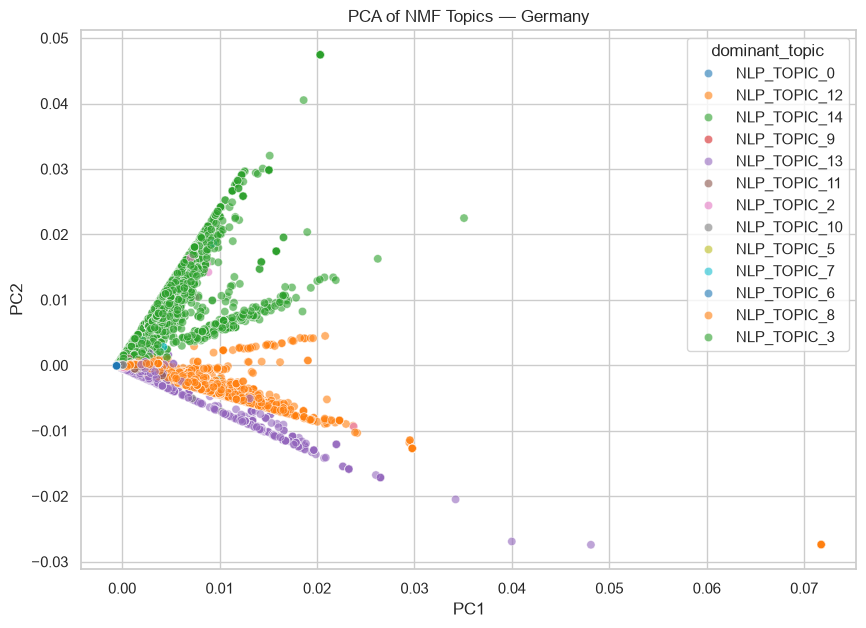

In [8]:
# PCA
plot_pca_topics(df_de, save=True, name="pca_topics_de")

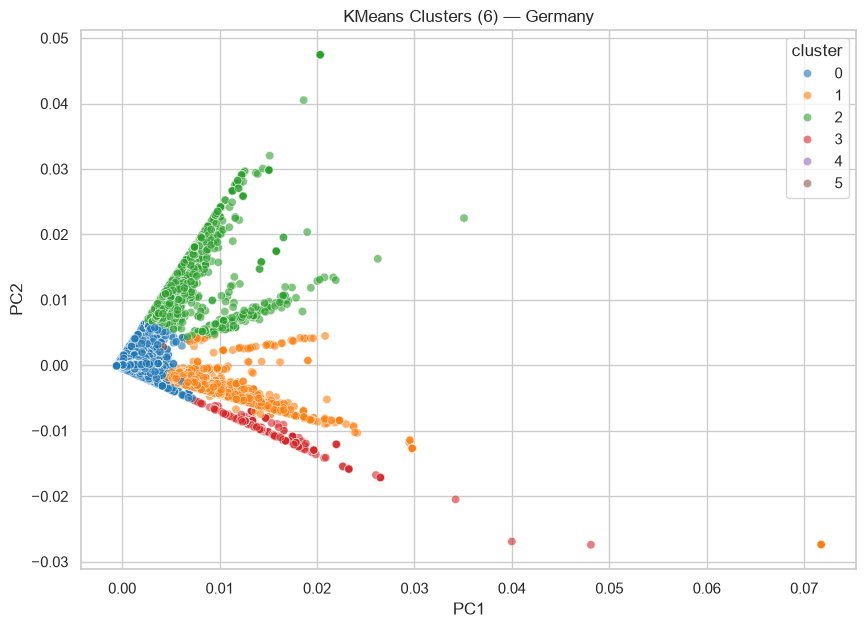

In [9]:
# KMeans
plot_kmeans_topics(df_de, n_clusters=6, save=True, name="kmeans_topics_de")

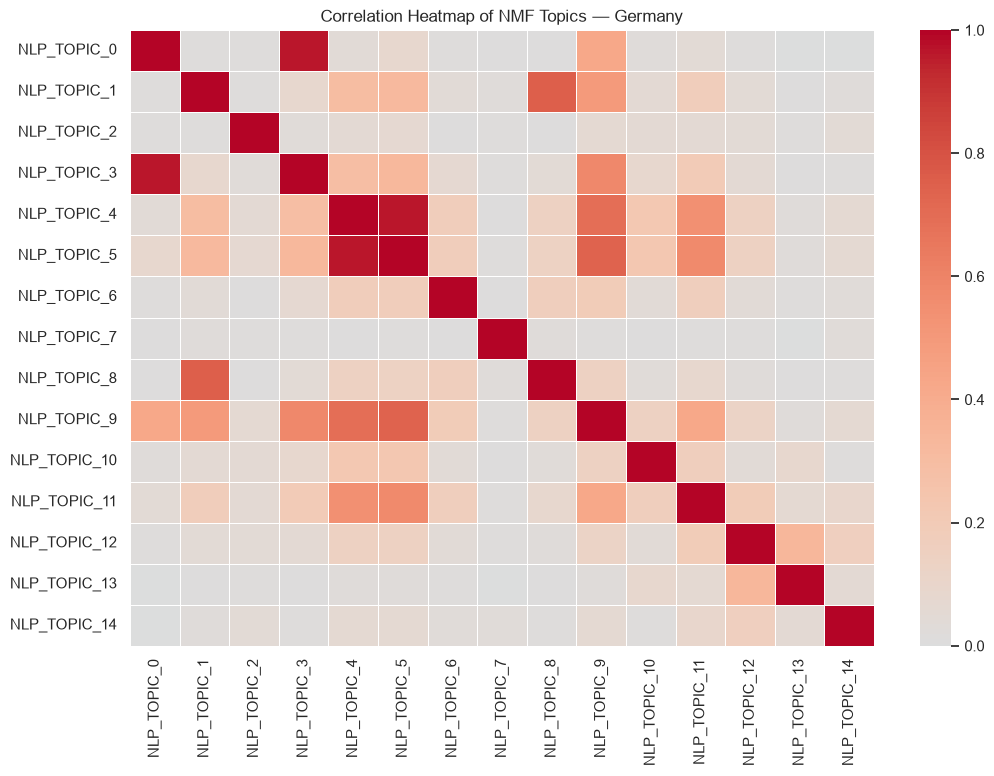

In [10]:
# Heatmap
plot_topic_heatmap(df_de, save=True, name="topic_heatmap_de")

#### Notes: Topic Structure Analysis for Germany (PCA, KMeans, Correlation)
1. PCA of NMF Topics
PCA shows that German tenders form distinct thematic regions driven by lot structure, technical scoring, service contracts, and quality‑dominant evaluation.
The most visible concentrations correspond to:
- Topic 0 (tender lots, procurement packages)
- Topic 6 (German technical criteria: Preis/Qualität)
- Topic 10 (service & management contracts)
- Topic 13 (quality‑dominant scoring)

2. KMeans Clusters
KMeans identifies stable clusters that represent typical German tender profiles.
Typical cluster patterns include:
- Cluster dominated by Topic 0 - lot‑structured tenders
- Cluster dominated by Topic 6 - technical scoring (Preis/Qualität)
- Cluster dominated by Topic 10 - service/management contracts
- Cluster dominated by Topic 13 - high‑weight quality evaluation
- Mixed clusters - tenders combining multiple scoring formulas (30/70, 40/60, 50/50)

3. Correlation Heatmap of NMF Topics
Correlation analysis confirms that topics are largely independent, with only scoring‑related topics showing moderate overlap.
KMeans identifies stable clusters that represent typical German tender profiles:
- Most topics are weakly correlated, indicating that they capture distinct semantic dimensions.
- A few moderate positive correlations appear between:
- Topic 7, Topic 8, Topic 11, Topic 13 - all related to price/quality scoring formulas.
- Topics such as Topic 0 (lot structure) and Topic 6 (technical criteria) remain largely independent, confirming their role as primary drivers of German procurement text.